In [11]:
import os
import sys
# modules=['NiaEnv/2022a', 'python/3.9.10', 'gcc/11.3.0', 'fftw/3.3.10']
# for mod in modules:
#     os.system("module --ignore_cache load "+mod)
sys.path.append(os.path.expanduser('~'))
import numpy as np 
from matplotlib import pyplot as plt
from datetime import datetime as dt
from albatros_analysis.src.correlations import baseband_data_classes as bdc
from albatros_analysis.src.utils import baseband_utils as butils
from albatros_analysis.src.utils import orbcomm_utils as outils
# from albatros_analysis.scripts.xcorr import helper
# from albatros_analysis.src.correlations import correlations as cr
import numba as nb
import time
#import timing
import importlib
import json
from scipy.optimize import minimize, differential_evolution

In [13]:
print(2**32)

4294967296


In [2]:
with open("/home/mohanagr/albatros_analysis/scripts/xcorr/config/config_gpu_7ant_jul22_satpulse.json") as f:
    config = json.load(f)
antpos=[]
for i, (ant, details) in enumerate(config["antennas"].items()):
        antpos.append(details["coordinates"])

PermissionError: [Errno 13] Permission denied: '/home/mohanagr/albatros_analysis/scripts/xcorr/config/config_gpu_7ant_jul22_satpulse.json'

In [3]:
antpos

[[79.41717895, -90.76721818, 188.095],
 [79.41721666666666, -90.75885, 176],
 [79.38845797, -91.01936185, 19.777],
 [79.4183154, -90.667425, 59.364],
 [79.3979952, -90.799868, 42.692],
 [79.41148497, -90.69528512, 32.593],
 [79.44377162, -90.71824306, 416.829]]

In [3]:
data=np.load("/scratch/thomasb/mohan/raw_ant=7_pol=2_cha=1834:1852_20251127T221535/raw_1753216695:1753216960_bit=1_ant=7_pol=2_cha=1834:1852_tim=246_upx=64_acc=1024_ipfb=0.2_complex64_regular_20251127T221535.npy")

PermissionError: [Errno 13] Permission denied: '/scratch/thomasb/mohan/raw_ant=7_pol=2_cha=1834:1852_20251127T221535/raw_1753216695:1753216960_bit=1_ant=7_pol=2_cha=1834:1852_tim=246_upx=64_acc=1024_ipfb=0.2_complex64_regular_20251127T221535.npy'

In [5]:
@nb.njit(parallel=True)
def apply_delay(arr, out, delay, freqs):
    # apply delay to an array of complex electric field or their correlation
    # does exp( j 2 pi nu tau) sign of tau is user dependent
    # freqs should correspond to the columns of the nspec x nchan array
    nspec = arr.shape[0]
    nchan = arr.shape[1]
    for i in nb.prange(nspec):
        for j in range(nchan):
            out[i, j] = arr[i, j] * np.exp(2j * np.pi * freqs[j] * delay[i])
    return out

@nb.njit(parallel=True)
def apply_delay_1d(arr, out, delay, freq):
    # apply delay to an array of complex electric field or their correlation
    # does exp( j 2 pi nu tau) sign of tau is user dependent
    # freqs should correspond to the columns of the nspec x nchan array
    nspec = arr.shape[0]
    for i in nb.prange(nspec):
            out[i] = arr[i] * np.exp(2j * np.pi * freq * delay[i])
    return out

@nb.njit(parallel=True)
def xcorr_avg(arr1,arr2,acclen):
    #helper function
    nblocks = arr1.shape[0]//acclen
    nchan = arr1.shape[1]
    out = np.zeros((nblocks,nchan),dtype=arr1.dtype)
    for i in nb.prange(nblocks):
        for j in range(acclen):
            for k in range(nchan):
                out[i,k] += arr1[i*acclen + j,k]*np.conj(arr2[i*acclen + j,k])
        out[i,:]/=acclen
    return out

@nb.njit(parallel=True)
def xcorr_avg_1d(arr1,arr2,acclen):
    #helper function
    nblocks = arr1.shape[0]//acclen
    out = np.zeros((nblocks,),dtype=arr1.dtype)
    for i in nb.prange(nblocks):
        for j in range(acclen):
                out[i] += arr1[i*acclen + j]*np.conj(arr2[i*acclen + j])
        out[i]/=acclen
    return out
        

In [6]:
data_slice = data[:,:,:,140].copy()

In [7]:
data.shape, data_slice.shape

((7, 2, 251904, 1152), (7, 2, 251904))

In [8]:
T_SPECTRA = 4096/250e6 * 64
print(T_SPECTRA)

0.001048576


In [13]:
def haversine(p1, p2, radius=6371000):
    """
    Vectorized Haversine distance using NumPy.

    Parameters
    ----------
    p1 : array-like of shape (..., 2)
        lat, lon in degrees
    p2 : array-like of shape (..., 2)
        lat, lon in degrees
    radius : float
        Earth radius (km by default)

    Returns
    -------
    distances : ndarray
        Distance(s) in the same unit as `radius`.
    """
    p1 = np.asarray(p1, dtype=float)
    p2 = np.asarray(p2, dtype=float)

    lat1 = np.radians(p1[..., 0])
    lon1 = np.radians(p1[..., 1])
    lat2 = np.radians(p2[..., 0])
    lon2 = np.radians(p2[..., 1])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    return radius * c

In [29]:
def objective(time_offset,data_slice,antpos,freq,plot=False):
    t_start=1753216695
    t_end=1753216960
    T_SPECTRA = 4096/250e6 * 64
    tle_path = outils.get_tle_file(t_start, "/project/rrg-sievers/mohanagr/OCOMM_TLES")
    ant_to_use = [0,2,3,4,5,6]
    chisq = 0
    # time_offset = time_offset[0]
    sum_wt = 0
    for i in range(len(ant_to_use)):
        for j in range(i+1, len(ant_to_use)):
            ai = ant_to_use[i]
            aj = ant_to_use[j]
            a1_coords=antpos[ai]
            a2_coords=antpos[aj]
            dist = haversine(a1_coords,a2_coords)
            sum_wt += dist**2
            dly = outils.get_sat_delay(
                                a1_coords,
                                a2_coords,
                                tle_path,
                                t_start+time_offset,
                                int(t_end-t_start)+1,
                                57166,
                                altaz=False
                            )
            delay = np.interp(
                np.arange(0, data.shape[2]) * T_SPECTRA, np.arange(0, int(t_end-t_start)+1), dly
            )
            acclen=1024
            spec2_phased = np.empty_like(data_slice[aj,0,:])
            spec2_phased = apply_delay_1d(data_slice[aj,0,:], spec2_phased, -delay, freq)
            Vxx = xcorr_avg_1d(data_slice[ai,0,:],spec2_phased,acclen)
            spec2_phased = apply_delay_1d(data_slice[aj,1,:], spec2_phased, -delay, freq)
            Vyy = xcorr_avg_1d(data_slice[ai,1,:],spec2_phased,acclen)
            V=(Vxx+Vyy)/2
            if plot:
                plt.plot(np.unwrap(np.angle(V))-np.angle(V)[0],label=f'{ai}-{aj}')
                plt.axhline(6.28, ls='--',c='black')
                plt.axhline(-6.28,ls='--', c='black')
                plt.legend()
            Vnew = np.exp(1j*np.angle(V))
            chisq-= dist**2*np.abs(np.mean(Vnew[:165]))**2 #cut it off where snr drops
    chisq/=sum_wt
    
    print("offset", time_offset, "chisq", chisq)
    return chisq

In [71]:
def objective2(pos_offset,time_offset,data_slice,antpos,freq,plot=False):
    t_start=1753216695
    t_end=1753216960
    T_SPECTRA = 4096/250e6 * 64
    tle_path = outils.get_tle_file(t_start, "/project/rrg-sievers/mohanagr/OCOMM_TLES")
    ant_to_use = [0,2,3,4,5,6]
    chisq = 0
    # time_offset = time_offset[0]
    sum_wt = 0
    for j in range(len(ant_to_use)):
        ai = 1
        aj = ant_to_use[j]
        a1_coords=antpos[ai]
        a2_coords=antpos[aj]
        dist = haversine(a1_coords,a2_coords)
        sum_wt += dist
        dly = outils.get_sat_delay(
                            [a1_coords[0]+1e-5*pos_offset[0], a1_coords[1]+1e-4*pos_offset[1], a1_coords[2]+pos_offset[2]],
                            a2_coords,
                            tle_path,
                            t_start+time_offset,
                            int(t_end-t_start)+1,
                            57166,
                            altaz=False
                        )
        delay = np.interp(
            np.arange(0, data.shape[2]) * T_SPECTRA, np.arange(0, int(t_end-t_start)+1), dly
        )
        acclen=1024
        spec2_phased = np.empty_like(data_slice[aj,0,:])
        spec2_phased = apply_delay_1d(data_slice[aj,0,:], spec2_phased, -delay, freq)
        Vxx = xcorr_avg_1d(data_slice[ai,0,:],spec2_phased,acclen)
        spec2_phased = apply_delay_1d(data_slice[aj,1,:], spec2_phased, -delay, freq)
        Vyy = xcorr_avg_1d(data_slice[ai,1,:],spec2_phased,acclen)
        V=(Vxx+Vyy)/2
        if plot:
            plt.plot(np.unwrap(np.angle(V))-np.angle(V)[0],label=f'{ai}-{aj}')
            plt.axhline(6.28, ls='--',c='black')
            plt.axhline(-6.28,ls='--', c='black')
            plt.legend()
        Vnew = np.exp(1j*np.angle(V))
        chisq-= dist * np.abs(np.mean(Vnew[:165]))**2 #cut it off where snr drops
    chisq/=sum_wt
    
    print("offset", pos_offset, "chisq", chisq)
    return chisq

In [50]:
t_start=1753216695
t_end=1753216960
a1_coords=[79.41717895, -90.76721818, 188.095]
a2_coords=[79.38845797, -91.01936185, 19.777] #m7
tle_path = outils.get_tle_file(t_start, "/project/rrg-sievers/mohanagr/OCOMM_TLES")
dly,altaz1,altaz2 = outils.get_sat_delay(
                    a1_coords,
                    a2_coords,
                    tle_path,
                    t_start,
                    int(t_end-t_start)+1,
                    57166,
                    altaz=True
                )
delay = np.interp(
    np.arange(0, data.shape[2]) * T_SPECTRA, np.arange(0, int(t_end-t_start)+1), dly
)

catalog #57166 epoch 2025-07-22 18:35:47 UTC


In [19]:
freqs = (np.arange(data.shape[-1])/64 + 1834)*250e6/4096
freqs = 250e6-freqs
print(freqs)
print(freqs.shape)
# lamda = 299792458/freq

[1.38061523e+08 1.38060570e+08 1.38059616e+08 ... 1.36965752e+08
 1.36964798e+08 1.36963844e+08]
(1152,)


In [27]:
freqs[140]

np.float64(137928009.03320312)

In [34]:
offsets = np.linspace(-0.6,-0.4,101)
chisqs = np.zeros(len(offsets),dtype='float64')
for i,offset in enumerate(offsets):
    chisqs[i]=objective(offset,data_slice,antpos,freqs[140])

catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
offset -0.6 chisq -0.1665135681202327
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 ep

In [36]:
offsets = np.linspace(-2,2,101)
chisqs2 = np.zeros(len(offsets),dtype='float64')
for i,offset in enumerate(offsets):
    chisqs2[i]=objective(offset,data_slice,antpos,freqs[140])

catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
offset -2.0 chisq -0.010129440227267826
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 

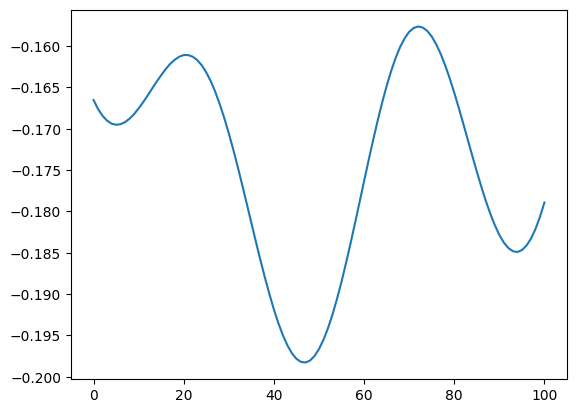

In [35]:
plt.plot(chisqs)

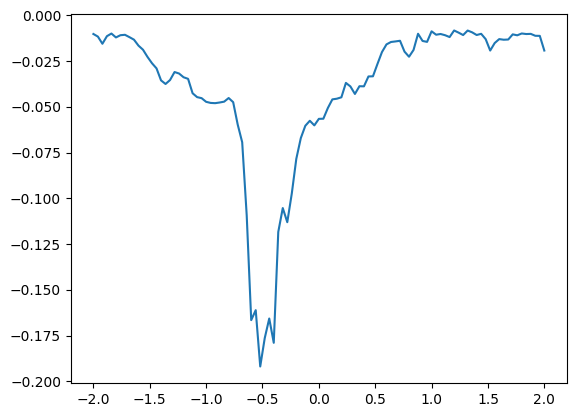

In [41]:
plt.plot(offsets,chisqs)
# plt.xlim(-1,0)

catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
offset 0 chisq -0.0697571922680864


np.float64(-0.0697571922680864)

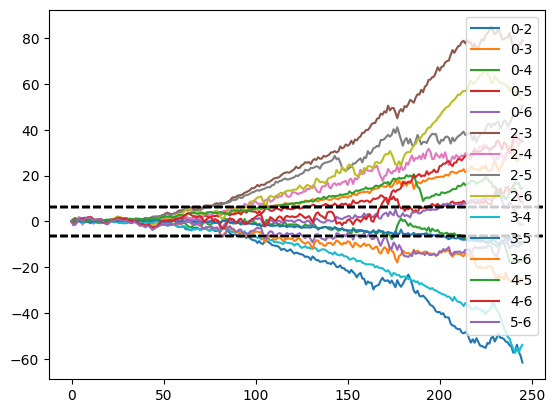

In [27]:
objective(0,data_slice,antpos,freqs[140],plot=True)

catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
offset -0.51 chisq -0.22674057159754227


np.float64(-0.22674057159754227)

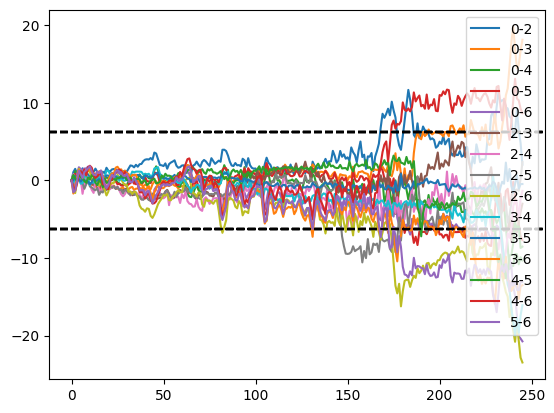

In [26]:
objective(-0.51,data_slice,antpos,freqs[140],plot=True) #baseline length weighting

catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
offset -0.507 chisq -0.19828489599911037


np.float64(-0.19828489599911037)

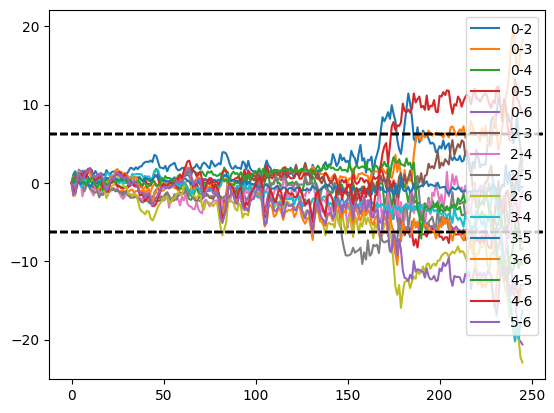

In [32]:
objective(-0.507,data_slice,antpos,freqs[140],plot=True) #baseline length^2 weighting

catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
offset -0.486 chisq -0.21117890904813438


np.float64(-0.21117890904813438)

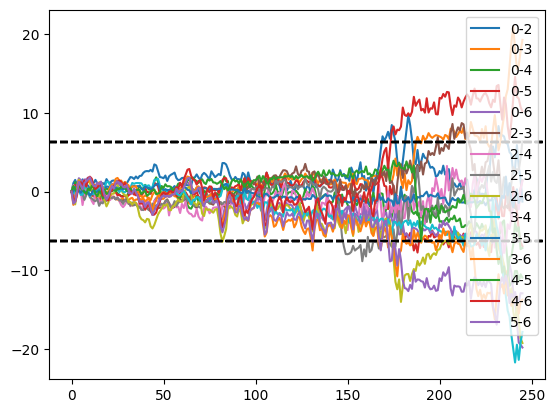

In [28]:
objective(-0.486,data_slice,antpos,freqs[140],plot=True)

In [44]:
minimize(objective,0,args=(data_slice, antpos, freqs[140]), method='L-BFGS-B',tol=1e-12)

catalog #57166 epoch 2025-07-22 18:35:47 UTC
offset 0.0 ant 2 chisq -3.7981782
catalog #57166 epoch 2025-07-22 18:35:47 UTC
offset 0.0 ant 3 chisq -24.365465
catalog #57166 epoch 2025-07-22 18:35:47 UTC
offset 0.0 ant 4 chisq -53.588245
catalog #57166 epoch 2025-07-22 18:35:47 UTC
offset 0.0 ant 5 chisq -120.03635
catalog #57166 epoch 2025-07-22 18:35:47 UTC
offset 0.0 ant 6 chisq -286.31976
catalog #57166 epoch 2025-07-22 18:35:47 UTC
offset 1e-08 ant 2 chisq -3.7981782
catalog #57166 epoch 2025-07-22 18:35:47 UTC
offset 1e-08 ant 3 chisq -24.365465
catalog #57166 epoch 2025-07-22 18:35:47 UTC
offset 1e-08 ant 4 chisq -53.588245
catalog #57166 epoch 2025-07-22 18:35:47 UTC
offset 1e-08 ant 5 chisq -120.03635
catalog #57166 epoch 2025-07-22 18:35:47 UTC
offset 1e-08 ant 6 chisq -286.31976


  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: -286.31976
        x: [ 0.000e+00]
      nit: 0
      jac: [ 0.000e+00]
     nfev: 2
     njev: 1
 hess_inv: <1x1 LbfgsInvHessProduct with dtype=float64>

In [80]:
minimize(objective2,( 4.999e+00,  2.092e-02,  4.075e+00),args=(-0.507,data_slice, antpos, freqs[140]), method='L-BFGS-B')

catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
offset [4.999   0.02092 4.075  ] chisq -0.3975733917371402
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
offset [4.99900001 0.02092    4.075     ] chisq -0.3975733917371402
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
offset [4.999      0.02092001 4.075     ] chisq -0.397573385018

  message: ABNORMAL: 
  success: False
   status: 2
      fun: -0.3975734842177943
        x: [ 4.999e+00  2.091e-02  4.075e+00]
      nit: 1
      jac: [ 0.000e+00  3.555e+00 -5.688e-02]
     nfev: 140
     njev: 35
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>

In [78]:
minimize(objective2,(2,-1,2),args=(-0.507,data_slice, antpos, freqs[140]), method='Nelder-Mead',bounds=((-5,5),(-5,5),(-10,10)))

catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
offset [ 2. -1.  2.] chisq -0.35059653318097406
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
offset [ 2.1 -1.   2. ] chisq -0.3515434669156845
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
offset [ 2.   -1.05  2.  ] chisq -0.35566867380981415
catalog #57166 epoch 2025-07-22 18:35:

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: -0.3975734246427624
             x: [ 4.999e+00  2.092e-02  4.075e+00]
           nit: 122
          nfev: 236
 final_simplex: (array([[ 4.999e+00,  2.092e-02,  4.075e+00],
                       [ 4.999e+00,  2.088e-02,  4.074e+00],
                       [ 4.999e+00,  2.090e-02,  4.074e+00],
                       [ 4.999e+00,  2.089e-02,  4.074e+00]]), array([-3.976e-01, -3.976e-01, -3.976e-01, -3.976e-01]))

In [72]:
minimize(objective2,(0,0,0),args=(-0.507,data_slice, antpos, freqs[140]), method='L-BFGS-B')

catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
offset [0. 0. 0.] chisq -0.04812818499400669
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
offset [1.e-08 0.e+00 0.e+00] chisq -0.04812818495481797
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
offset [0.e+00 1.e-08 0.e+00] chisq -0.04812817354953571
catalog #57166 epoch 2025-07-22

  message: ABNORMAL: 
  success: False
   status: 2
      fun: -0.39019083984490216
        x: [ 2.104e+00 -1.280e+00  2.489e+00]
      nit: 4
      jac: [ 3.688e+00  4.692e+00  3.673e+00]
     nfev: 256
     njev: 64
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>

catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
offset -0.507 chisq -0.3214964


np.float32(-0.3214964)

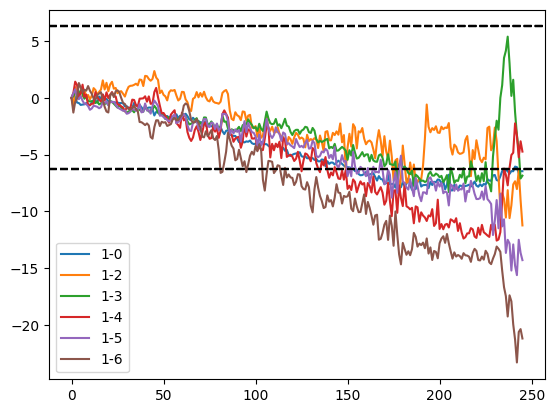

In [49]:
objective2((0,0,0),-0.507,data_slice,antpos,freqs[140],plot=True) #now let's try to fit ant2 position, no weighting

catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
offset (4.999, 0.02092, 4.075) chisq -0.3975733917371402


np.float64(-0.3975733917371402)

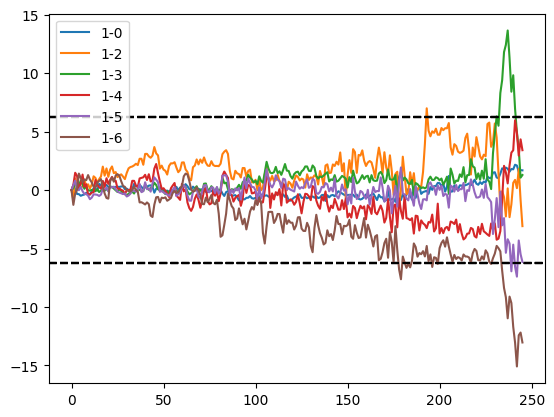

In [82]:
objective2(( 4.999e+00,  2.092e-02,  4.075e+00),-0.507,data_slice,antpos,freqs[140],plot=True) #now let's try to fit ant2 position, no weighting

catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
offset (-0.000289, -6.88e-05) chisq -0.17440057493775835


np.float64(-0.17440057493775835)

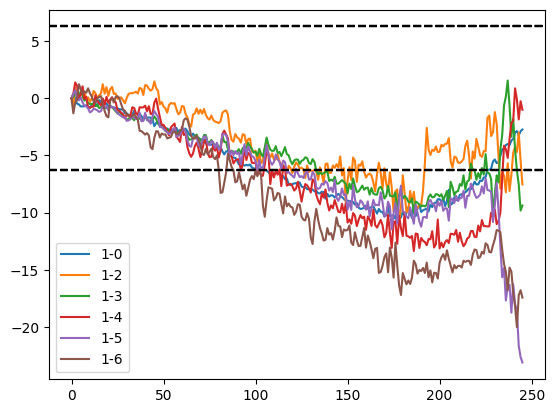

In [65]:
objective2((-2.89e-4,-6.88e-5),-0.507,data_slice,antpos,freqs[140],plot=True) #now let's try to fit ant2 position, no weighting

In [60]:
differential_evolution(objective2, ((-1e-3,1e-3),(-1e-3,1e-3),(-5,5)), args=(-0.507,data_slice, antpos, freqs[140]),maxiter=5)

catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
offset [-2.77876710e-04  8.47074099e-04 -7.00861316e-01] chisq -0.04505197186107454
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
offset [3.92919843e-04 6.41467233e-04 4.07953539e+00] chisq -0.09262112223341878
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC
offset [-1.11262579e-04  

             message: Maximum number of iterations has been exceeded.
             success: False
                 fun: -0.39989762740483575
                   x: [ 5.660e-04 -1.202e-04 -3.355e+00]
                 nit: 5
                nfev: 470
          population: [[ 5.979e-04 -7.661e-05 -3.355e+00]
                       [ 1.151e-04 -3.205e-04 -1.855e+00]
                       ...
                       [ 6.002e-04  2.416e-04 -4.415e-01]
                       [ 1.695e-04 -1.417e-04  2.871e+00]]
 population_energies: [-3.999e-01 -3.248e-01 ... -2.499e-01 -2.665e-01]
                 jac: [ 9.016e+00  8.066e+00  4.461e-02]

In [53]:
# acclen=256
# spec1=data[0,1,:,:].copy()
# spec2=data[1,0,:,:].copy()
# spec2_phased = np.empty_like(spec2)
# spec2_phased = apply_delay(spec2, spec2_phased, delay, freqs)
# Vyx1 = xcorr_avg(spec1,spec2_phased,acclen)
acclen=1024
spec1=data[0,0,:,:].copy()
spec2=data[1,0,:,:].copy()
spec2_phased = np.empty_like(spec2)
spec2_phased = apply_delay(spec2, spec2_phased, -delay, freqs)
Vxx = xcorr_avg(spec1,spec2_phased,acclen)

acclen=1024
spec1=data[0,1,:,:].copy()
spec2=data[1,1,:,:].copy()
spec2_phased = np.empty_like(spec2)
spec2_phased = apply_delay(spec2, spec2_phased, -delay, freqs)
Vyy = xcorr_avg(spec1,spec2_phased,acclen)

V=(Vxx+Vyy)/2

In [143]:
# acclen=256
# spec1=data[0,1,:,:].copy()
# spec2=data[1,0,:,:].copy()
# spec2_phased = np.empty_like(spec2)
# spec2_phased = apply_delay(spec2, spec2_phased, delay, freqs)
# Vyx1 = xcorr_avg(spec1,spec2_phased,acclen)
acclen=1024
spec1=data[0,0,:,:].copy()
spec2=data[1,0,:,:].copy()
spec2_phased = np.empty_like(spec2)
spec2_phased = apply_delay(spec2, spec2_phased, -delay2, freqs)
Vxx = xcorr_avg(spec1,spec2_phased,acclen)

acclen=1024
spec1=data[0,1,:,:].copy()
spec2=data[1,1,:,:].copy()
spec2_phased = np.empty_like(spec2)
spec2_phased = apply_delay(spec2, spec2_phased, -delay2, freqs)
Vyy = xcorr_avg(spec1,spec2_phased,acclen)

V2=(Vxx+Vyy)/2

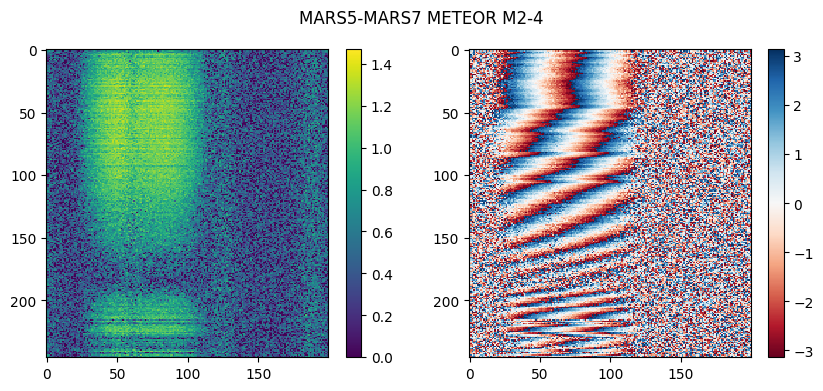

In [44]:
fig=plt.gcf()
fig.set_size_inches(10,4)
plt.suptitle("MARS5-MARS7 METEOR M2-4")
fstart=100
fstop=300
# extent=[freqs[fstart]/1e6,freqs[fstop]/1e6,Vyx.shape[0]*T_SPECTRA*acclen,0]
plt.subplot(121)
plt.imshow(np.log10(np.abs(V[:,fstart:fstop])),aspect='auto',interpolation='none',cmap='viridis',vmin=0)
plt.colorbar()
plt.subplot(122)
plt.imshow(np.angle(V)[:,fstart:fstop],aspect='auto',interpolation='none',cmap='RdBu')
plt.colorbar()
# plt.xlim(0,120)

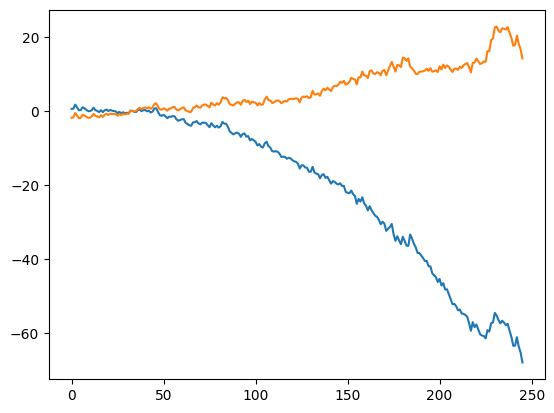

In [78]:
plt.plot(np.unwrap(np.angle(V[:,150])))
plt.plot(np.unwrap(np.angle(V2[:,150])))

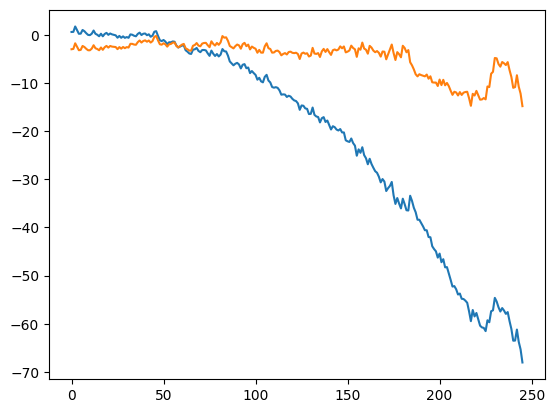

In [144]:
plt.plot(np.unwrap(np.angle(V[:,150])))
plt.plot(np.unwrap(np.angle(V2[:,150])))

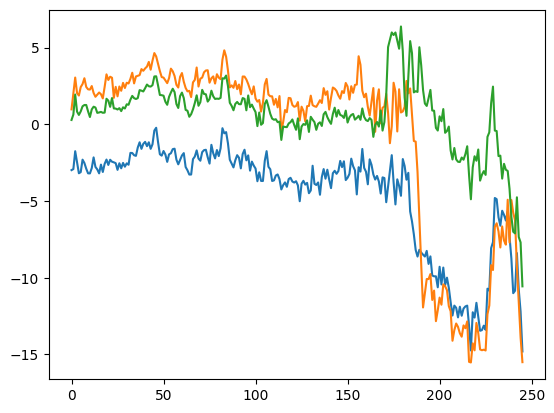

In [146]:
plt.plot(np.unwrap(np.angle(V2[:,150])))
plt.plot(np.unwrap(np.angle(V2[:,160])))
plt.plot(np.unwrap(np.angle(V2[:,170])))

In [165]:
ph1=np.unwrap(np.angle(V[:,150]))
ph1-=ph1.mean()
ph2=np.unwrap(np.angle(V2[:,150]))
ph2-=ph2.mean()
fx1=np.fft.rfft(ph1)
fx2=np.fft.rfft(ph2)

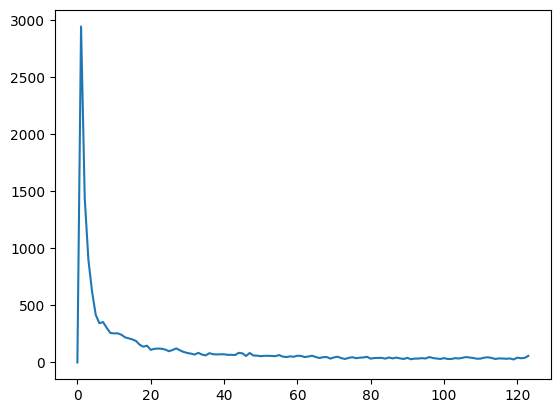

In [166]:
plt.plot(np.abs(fx1))

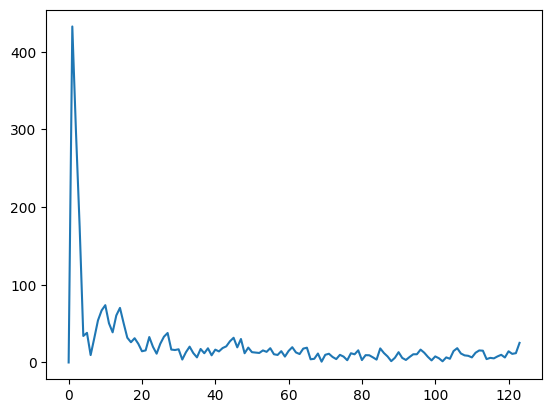

In [167]:
plt.plot(np.abs(fx2))

In [9]:
ix=40*acclen
blocksize=acclen
# chanids=100+np.arange(30,110)
chanids=np.arange(127,212)
chan=4096*64-(1834*64+chanids)
freq=chan*250e6/4096/64
print(chan)
print(len(freq))

[144641 144640 144639 144638 144637 144636 144635 144634 144633 144632
 144631 144630 144629 144628 144627 144626 144625 144624 144623 144622
 144621 144620 144619 144618 144617 144616 144615 144614 144613 144612
 144611 144610 144609 144608 144607 144606 144605 144604 144603 144602
 144601 144600 144599 144598 144597 144596 144595 144594 144593 144592
 144591 144590 144589 144588 144587 144586 144585 144584 144583 144582
 144581 144580 144579 144578 144577 144576 144575 144574 144573 144572
 144571 144570 144569 144568 144567 144566 144565 144564 144563 144562
 144561 144560 144559 144558 144557]
85


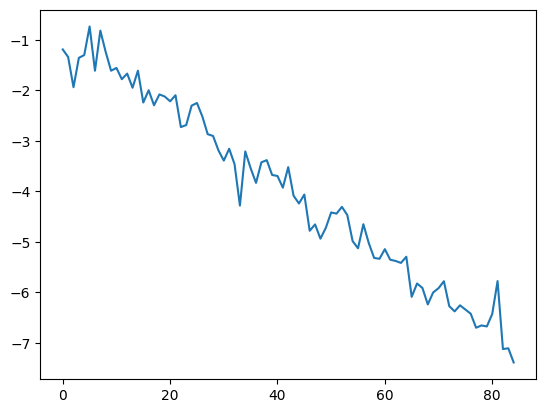

In [20]:
plt.plot(np.unwrap(np.angle(Vyx2)[18,127:125+87]))

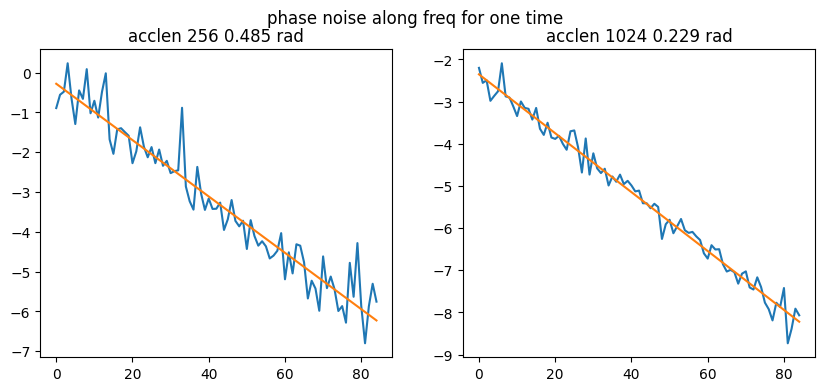

In [80]:
rowid=225
x = np.arange(len(chanids))
y = np.unwrap(np.angle(Vyx1[rowid,chanids]))
m, c = np.polyfit(x, y, 1)
yfit1 = m*x + c
residual = y - yfit1
sigma_phi1 = np.sqrt(np.mean(residual**2))
y = np.unwrap(np.angle(Vyx2[rowid,chanids]))
m, c = np.polyfit(x, y, 1)
yfit2 = m*x + c
residual = y - yfit2
sigma_phi2 = np.sqrt(np.mean(residual**2))


fig=plt.gcf()
fig.set_size_inches(10,4)
plt.suptitle("phase noise along freq for one time")
plt.subplot(121)
plt.title(f"acclen 256 {sigma_phi1:5.3f} rad")
plt.plot(np.unwrap(np.angle(Vyx1)[rowid,chanids]))
plt.plot(x,yfit1)
plt.subplot(122)
plt.title(f"acclen 1024 {sigma_phi2:5.3f} rad")
plt.plot(np.unwrap(np.angle(Vyx2)[rowid,chanids]))
plt.plot(x,yfit2)

In [81]:
0.265/0.229

1.1572052401746724

In [51]:
print("clock delay noise % (2pi)", 0.264/(2*np.pi*137e6))

clock delay noise % (2pi) 3.066927370529954e-10


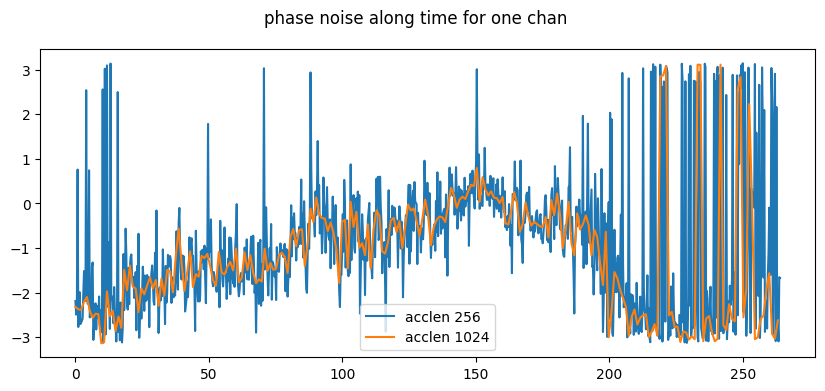

In [78]:
fig=plt.gcf()
fig.set_size_inches(10,4)
plt.suptitle("phase noise along time for one chan")
Vyx1 = xcorr_avg(spec1,spec2_phased,256)
Vyx2 = xcorr_avg(spec1,spec2_phased,1024)
plt.plot(np.arange(Vyx1.shape[0])*T_SPECTRA*256, np.angle(Vyx1[:,140]),label='acclen 256')
plt.plot(np.arange(Vyx2.shape[0])*T_SPECTRA*1024,np.angle(Vyx2[:,140]),label='acclen 1024')
plt.legend()
# plt.xlim(100,200)

In [65]:
uph=np.zeros((Vyx2.shape[0],len(chanids)),dtype='complex128')
ref_time_idx = 0
ref_phase = np.angle(Vyx2[ref_time_idx,chanids])
for i in range(Vyx2.shape[0]):
    cur_phase = np.angle(Vyx2[i,chanids])
    uph[i,:]=Vyx2[i,chanids]*np.exp(1j*(ref_phase - cur_phase))

In [68]:
chanids

array([127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139,
       140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152,
       153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165,
       166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178,
       179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191,
       192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204,
       205, 206, 207, 208, 209, 210, 211])

In [69]:
ps = np.zeros((Vyx2.shape[0],4096*64//2+1),dtype='complex128')
ps[:,(1834*64+chanids)]=Vyx2[:,chanids]
corr = np.fft.irfft(ps,axis=1)

In [70]:
corr.shape

(246, 262144)

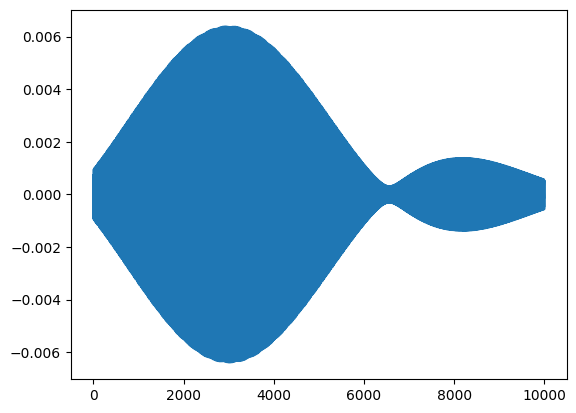

In [75]:
plt.plot(corr[50,:10000])

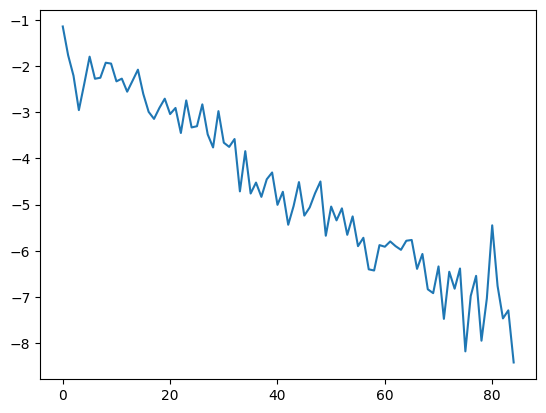

In [67]:
uph_avg = np.mean(uph,axis=0)
plt.plot(np.unwrap(np.angle(uph_avg)))

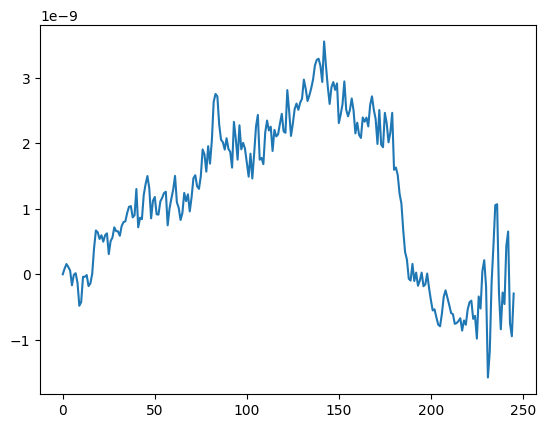

In [48]:
plt.plot(np.mean(uph,axis=0))

In [44]:
importlib.reload(timing)

<module 'timing' from '/home/mohanagr/Jupyter/MARS all ant xcorr debug/timing.py'>

In [ ]:
plt.plot(np.angle(Vyx2[:,140]))

Text(0, 0.5, 'times')

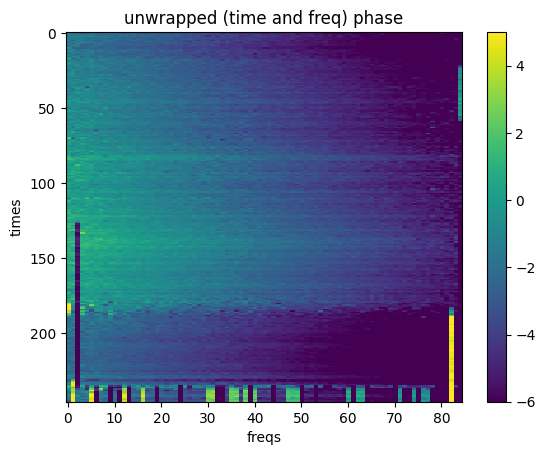

In [12]:
a=np.unwrap(np.angle(Vyx2[:,chanids]),axis=1)
b=np.unwrap(a,axis=0)
plt.imshow(b,aspect='auto',interpolation='none',vmin=-6,vmax=5)
plt.colorbar()
plt.title("unwrapped (time and freq) phase")
plt.xlabel("freqs")
plt.ylabel("times")

### Fit one long block

In [23]:
acclen

1024

In [100]:
ix=10*acclen
blocksize=150*acclen
print(ix,blocksize)
y1=spec1[ix:ix+blocksize,chanids]
y2=spec2_phased[ix:ix+blocksize,chanids]
xc_small = y1*np.conj(y2)
expected_delta = 0
if np.abs(expected_delta) < 1e-15: expected_delta = 1e-15
# print("Starting point", expected_delta)
# print(f"Block {i} Expected delta={expected_delta}")
alpha=timing.lmsolver(xc_small,expected_delta,chan,lamda=10,ftol=1e-8,xtol=1e-8,niter=100)
f_no_correction = timing.objective_func(xc_small,0,chan)
f_wi_correction = timing.objective_func(xc_small,alpha,chan)
improvement = (f_wi_correction[0]-f_no_correction[0])*100/f_no_correction[0]
print(f"alpha={alpha:4.2e}", f"improvement of {improvement:4.2f}%")

10240 153600
alpha=-1.71e-11 improvement of 68.17%


In [101]:
b.shape

(246, 80)

(80,)

In [105]:
T_SPECTRA

0.001048576

In [115]:
nu

array([1.37937546e+08, 1.37936592e+08, 1.37935638e+08, 1.37934685e+08,
       1.37933731e+08, 1.37932777e+08, 1.37931824e+08, 1.37930870e+08,
       1.37929916e+08, 1.37928963e+08, 1.37928009e+08, 1.37927055e+08,
       1.37926102e+08, 1.37925148e+08, 1.37924194e+08, 1.37923241e+08,
       1.37922287e+08, 1.37921333e+08, 1.37920380e+08, 1.37919426e+08,
       1.37918472e+08, 1.37917519e+08, 1.37916565e+08, 1.37915611e+08,
       1.37914658e+08, 1.37913704e+08, 1.37912750e+08, 1.37911797e+08,
       1.37910843e+08, 1.37909889e+08, 1.37908936e+08, 1.37907982e+08,
       1.37907028e+08, 1.37906075e+08, 1.37905121e+08, 1.37904167e+08,
       1.37903214e+08, 1.37902260e+08, 1.37901306e+08, 1.37900352e+08,
       1.37899399e+08, 1.37898445e+08, 1.37897491e+08, 1.37896538e+08,
       1.37895584e+08, 1.37894630e+08, 1.37893677e+08, 1.37892723e+08,
       1.37891769e+08, 1.37890816e+08, 1.37889862e+08, 1.37888908e+08,
       1.37887955e+08, 1.37887001e+08, 1.37886047e+08, 1.37885094e+08,
      

In [43]:
y = b[:100].copy()
y_flat = np.ravel(y)
nu=freqs[chanids].copy()/1e9
tt=np.arange(y.shape[0])*T_SPECTRA*acclen/100
Nt = tt.shape[0]
Nf = nu.shape[0]
print(Nf,Nt)
two_pi = 2*np.pi
# precompute sums over freq/time
S_nu   = np.sum(nu)
S_nu2  = np.sum(nu*nu)
S_t    = np.sum(tt)
S_t2   = np.sum(tt*tt)
print(S_nu2, S_t2)
# Normal matrix components
M11 = (two_pi**2) * S_nu2 * S_t2          # < (2π ν t)^2 >
M12 = (two_pi**2) * S_nu2 * S_t           # < (2π ν t)*(2π ν) >
M13 = two_pi * S_nu * S_t                 # < (2π ν t)*1 >
M22 = (two_pi**2) * S_nu2 * Nt            # < (2π ν)^2 >
M23 = two_pi * S_nu * Nt                  # < (2π ν)*1 >
M33 = Nt * Nf                             # < 1*1 >

A_T_A = np.array([
    [M11, M12, M13],
    [M12, M22, M23],
    [M13, M23, M33]
], dtype=float)

# # # Normal matrix components
# M11 = S_t2  * Nf        
# M12 = two_pi * S_nu * S_t           
# M13 = S_t * Nf               
# M22 = (two_pi**2) * S_nu2 * Nt          
# M23 = two_pi * S_nu * Nt                
# M33 = Nt * Nf

# A_T_A = np.array([
#     [M11, M12, M13],
#     [M12, M22, M23],
#     [M13, M23, M33]
# ], dtype=float)

# # Normal matrix (2x2) entries (factor (2π)^2)
# a11 = (two_pi**2) * S_nu2 * S_t2
# a12 = (two_pi**2) * S_nu2 * S_t
# a22 = (two_pi**2) * S_nu2 * Nt

# A_T_A = np.array([[a11, a12],
#                   [a12, a22]], dtype=float)

# Normal matrix (2x2) entries (factor (2π)^2)
# a11 = (two_pi**2) * S_nu2
# a12 = (two_pi) * S_nu
# a22 =  Nf

# A_T_A = np.array([[a11, a12],
#                   [a12, a22]], dtype=float)

AtAinv = np.linalg.inv(A_T_A)
print(A_T_A)
print(AtAinv)

85 100
1.6164031596917994 37.85617760376583
[[2415.71773613 3391.67707772 3914.43638141]
 [3391.67707772 6381.30389553 7364.85448263]
 [3914.43638141 7364.85448263 8500.        ]]
[[ 1.63123117e-03 -8.67002953e-04 -5.08010922e-12]
 [-8.67002958e-04  5.44282919e+03 -4.71595783e+03]
 [-0.00000000e+00 -4.71595783e+03  4.08615814e+03]]


In [14]:
np.sqrt(np.diag(AtAinv))*0.264

array([1.06625648e-13, 1.94767406e-08, 1.68756890e+01])

In [28]:
np.sqrt(np.diag(AtAinv))*0.264

array([9.23861636e-05, 1.94767398e-08, 1.68756897e+01])

In [130]:
np.sqrt(np.diag(AtAinv))*0.264

array([2.13311145e-07, 1.84823544e+02])

In [26]:
nn=Nf
np.sqrt(12/(nn*(nn**2 - 1))) * 0.264/(250e6/4096/64)/two_pi/np.sqrt(50) #one row is roughly one sec. 

np.float64(2.7544269637905722e-08)

In [25]:
nn=Nf
np.sqrt(12/(nn*(nn**2 - 1))) * 0.264/(250e6/4096/64)/two_pi/np.sqrt(100) #one row is roughly one sec. 

np.float64(1.9476739843793866e-08)

In [61]:
import numpy as np

# Inputs:
# baselines: list of (i, j) pairs using 0..Nant-1, reference antenna 0 fixed
# nu : array shape (Nf,)  (Hz)
# t  : array shape (Nt,)  (s)
# note: we assume you stack data with freq fastest per baseline/time to form RHS separately

nant=7
nbl = nant*(nant-1)//2
C = np.zeros((nbl, nant-1),dtype='float64')
rowidx=0
for i in range(nant):
    for j in range(i+1,nant):
        C[rowidx,j-1]=1
        if i>0:
            C[rowidx,i-1]=-1
        rowidx+=1
print(C)
print(C.shape)
print(C.T@C)
u,s,vh=np.linalg.svd(C)
print(s)

M = C.T @ C   # shape (Nant_eff, Nant_eff)

Npar = 3 * (nant-1)
big_AtA = np.zeros((Npar, Npar), dtype=float)
for p in range(nant-1):
    for q in range(nant-1):
        big_AtA[3*p:3*p+3, 3*q:3*q+3] = M[p, q] * A_T_A


[[ 1.  0.  0.  0.  0.  0.]
 [ 0.  1.  0.  0.  0.  0.]
 [ 0.  0.  1.  0.  0.  0.]
 [ 0.  0.  0.  1.  0.  0.]
 [ 0.  0.  0.  0.  1.  0.]
 [ 0.  0.  0.  0.  0.  1.]
 [-1.  1.  0.  0.  0.  0.]
 [-1.  0.  1.  0.  0.  0.]
 [-1.  0.  0.  1.  0.  0.]
 [-1.  0.  0.  0.  1.  0.]
 [-1.  0.  0.  0.  0.  1.]
 [ 0. -1.  1.  0.  0.  0.]
 [ 0. -1.  0.  1.  0.  0.]
 [ 0. -1.  0.  0.  1.  0.]
 [ 0. -1.  0.  0.  0.  1.]
 [ 0.  0. -1.  1.  0.  0.]
 [ 0.  0. -1.  0.  1.  0.]
 [ 0.  0. -1.  0.  0.  1.]
 [ 0.  0.  0. -1.  1.  0.]
 [ 0.  0.  0. -1.  0.  1.]
 [ 0.  0.  0.  0. -1.  1.]]
(21, 6)
[[ 6. -1. -1. -1. -1. -1.]
 [-1.  6. -1. -1. -1. -1.]
 [-1. -1.  6. -1. -1. -1.]
 [-1. -1. -1.  6. -1. -1.]
 [-1. -1. -1. -1.  6. -1.]
 [-1. -1. -1. -1. -1.  6.]]
[2.64575131 2.64575131 2.64575131 2.64575131 2.64575131 1.        ]


In [62]:
u,s,vh= np.linalg.svd(big_AtA)

In [63]:
0.264*np.sqrt(np.diag(np.linalg.inv(big_AtA)))

array([5.69938060e-03, 1.04107557e+01, 9.02043516e+00, 5.69938060e-03,
       1.04107557e+01, 9.02043514e+00, 5.69938060e-03, 1.04107557e+01,
       9.02043513e+00, 5.69938060e-03, 1.04107557e+01, 9.02043513e+00,
       5.69938060e-03, 1.04107557e+01, 9.02043513e+00, 5.69938060e-03,
       1.04107557e+01, 9.02043515e+00])

### Fit multiple blocks

In [100]:
blocksize=16384
nblocks = spec1.shape[0]//blocksize
fit_alpha = np.zeros(nblocks,dtype='float64')
fit_slope = np.zeros(nblocks,dtype='float64')
fit_slope_err = np.zeros(nblocks,dtype='float64')
phase_noise_rms = np.zeros(nblocks,dtype='float64')
xc_phased = np.empty((nblocks,len(chanids)),dtype='complex64')

In [101]:
n = np.arange(blocksize)
for i in range(nblocks):
    ix = i*blocksize
    y1=spec1[ix:ix+blocksize,chanids]
    y2=spec2_phased[ix:ix+blocksize,chanids]
    xc_small = y1*np.conj(y2)
    expected_delta = 0
    if np.abs(expected_delta) < 1e-15: expected_delta = 1e-15
    # print("Starting point", expected_delta)
    # print(f"Block {i} Expected delta={expected_delta}")
    alpha=timing.lmsolver(xc_small,expected_delta,chan,lamda=10,ftol=1e-8,xtol=1e-8,niter=100)
    xc_phased[i,:] = np.mean(xc_small*np.exp(2j*np.pi*chan[np.newaxis,:]*n[:,np.newaxis]*alpha),axis=0)
    x = np.arange(len(chanids))
    y = np.unwrap(np.angle(xc_phased[i,:]))
    # linear fit
    m, c = np.polyfit(x, y, 1)
    # predicted phase
    yfit = m*x + c
    # phase noise RMS (input noise)
    residual = y - yfit
    sigma_phi = np.sqrt(np.mean(residual**2))
    nn = len(x)
    # slope uncertainty (phase units per channel)
    sigma_m = np.sqrt(12/(nn*(nn**2 - 1))) * sigma_phi
    # convert both slope and slope error to delay units
    fit_slope[i] = m*4096*64/(2*np.pi)
    fit_slope_err[i] = sigma_m*4096*64/(2*np.pi)
    phase_noise_rms[i] = sigma_phi
    # store phase noise RMS
    phase_noise_rms[i] = sigma_phi
    f_no_correction = timing.objective_func(xc_small,0,chan)
    f_wi_correction = timing.objective_func(xc_small,alpha,chan)
    improvement = (f_wi_correction[0]-f_no_correction[0])*100/f_no_correction[0]
    print("blocknum", i, f"alpha={alpha:4.2e}", f"improvement of {improvement:4.2f}%")
    fit_alpha[i]=alpha

blocknum 0 alpha=1.44e-11 improvement of 0.35%
blocknum 1 alpha=-1.66e-11 improvement of 0.47%
blocknum 2 alpha=-3.27e-11 improvement of 2.06%
blocknum 3 alpha=-1.77e-11 improvement of 0.59%
blocknum 4 alpha=-5.84e-11 improvement of 6.57%
blocknum 5 alpha=2.52e-11 improvement of 1.14%
blocknum 6 alpha=-1.03e-11 improvement of 0.20%
blocknum 7 alpha=-2.81e-11 improvement of 1.46%
blocknum 8 alpha=-4.60e-11 improvement of 3.95%
blocknum 9 alpha=2.75e-11 improvement of 1.41%
blocknum 10 alpha=3.34e-13 improvement of 0.00%
blocknum 11 alpha=1.73e-10 improvement of 104.47%
blocknum 12 alpha=4.41e-11 improvement of 3.48%
blocknum 13 alpha=1.14e-11 improvement of 0.24%
blocknum 14 alpha=-4.50e-11 improvement of 2.85%


(-300.0, 300.0)

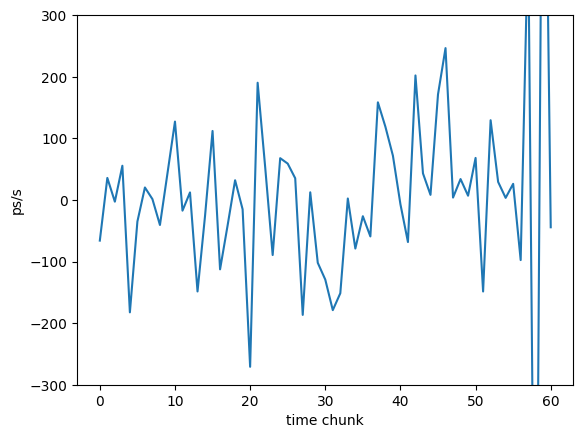

In [66]:
plt.plot(fit_alpha*1e12)
plt.ylabel("ps/s")
plt.xlabel("time chunk")
plt.ylim(-300,300)

Text(0.5, 0, 'time chunk')

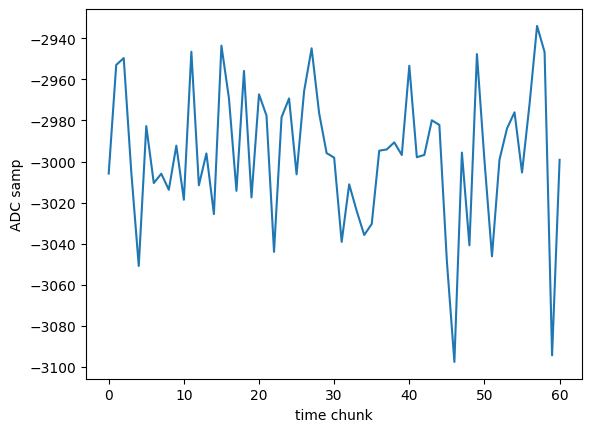

In [95]:
plt.plot(fit_slope)
plt.ylabel("ADC samp")
plt.xlabel("time chunk")

Text(0.5, 0, 'time chunk')

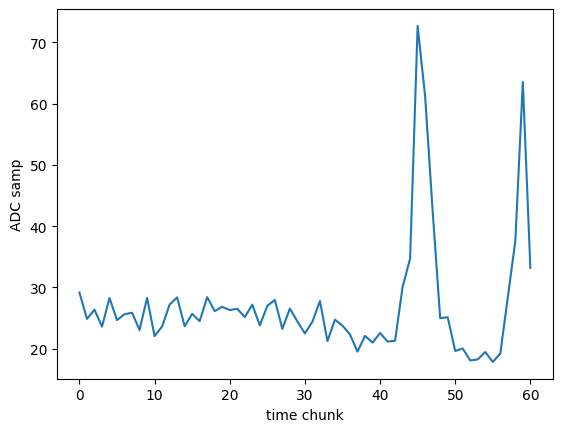

In [99]:
plt.plot(fit_slope_err)
plt.ylabel("ADC samp")
plt.xlabel("time chunk")

Text(0.5, 0, 'time chunk')

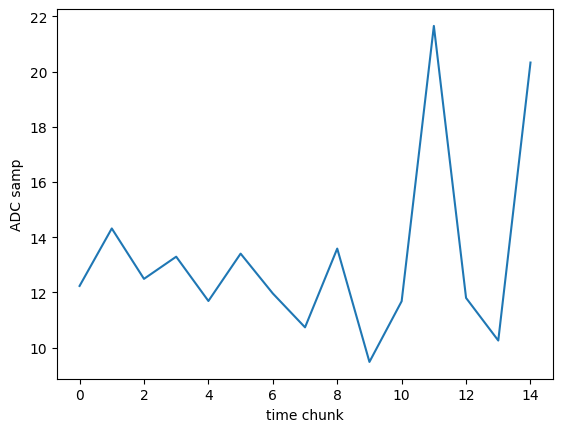

In [102]:
plt.plot(fit_slope_err)
plt.ylabel("ADC samp")
plt.xlabel("time chunk")
#16 sec of averaging

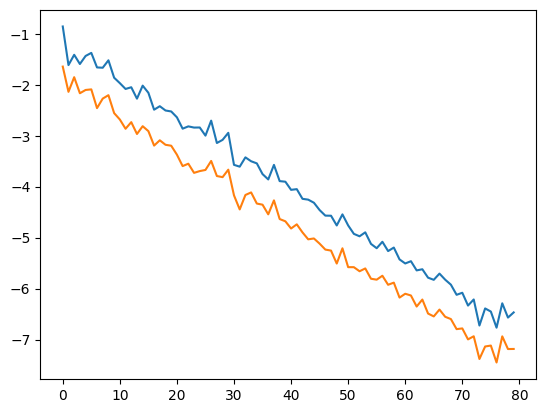

In [82]:
plt.plot(np.unwrap(np.angle(xc_phased)[57,:]))
plt.plot(np.unwrap(np.angle(Vyx)[57,chanids]))

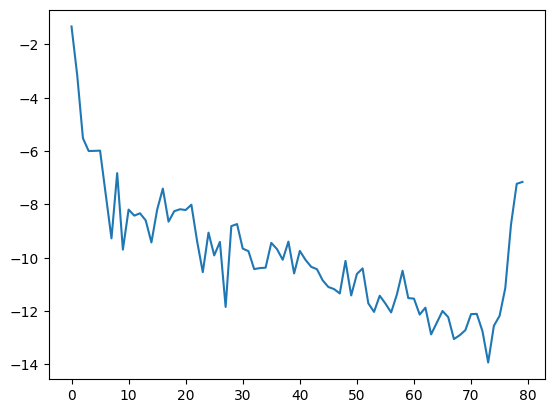

In [79]:
plt.plot(np.unwrap(np.angle(Vyx)[59,chanids]))

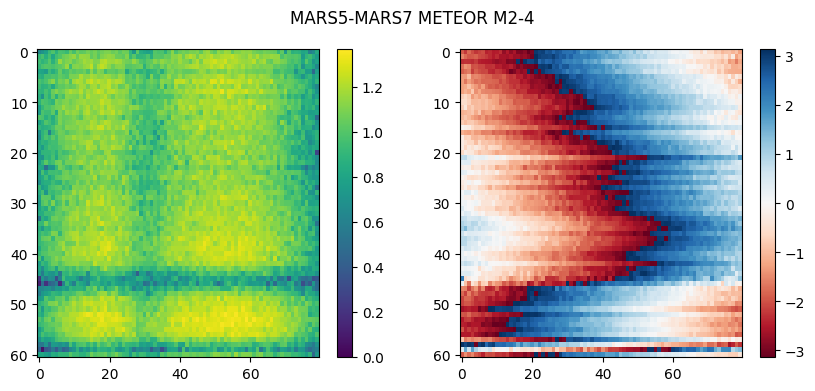

In [59]:
fig=plt.gcf()
fig.set_size_inches(10,4)
plt.suptitle("MARS5-MARS7 METEOR M2-4")
fstart=100
fstop=300
extent=[freqs[fstart]/1e6,freqs[fstop]/1e6,xcorr.shape[0]*T_SPECTRA*acclen,0]
plt.subplot(121)
plt.imshow(np.log10(np.abs(xc_phased)[:,:]),aspect='auto',interpolation='none',cmap='viridis',vmin=0)
plt.colorbar()
plt.subplot(122)
plt.imshow(np.angle(xc_phased)[:,:],aspect='auto',interpolation='none',cmap='RdBu')
plt.colorbar()


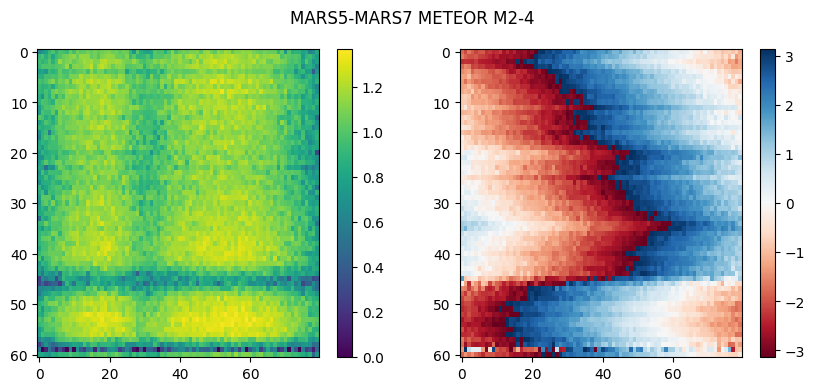

In [58]:
fig=plt.gcf()
fig.set_size_inches(10,4)
plt.suptitle("MARS5-MARS7 METEOR M2-4")
fstart=100
fstop=300
extent=[freqs[fstart]/1e6,freqs[fstop]/1e6,xcorr.shape[0]*T_SPECTRA*acclen,0]
plt.subplot(121)
plt.imshow(np.log10(np.abs(Vyx)[:,chanids]),aspect='auto',interpolation='none',cmap='viridis',vmin=0)
plt.colorbar()
plt.subplot(122)
plt.imshow(np.angle(Vyx)[:,chanids],aspect='auto',interpolation='none',cmap='RdBu')
plt.colorbar()

In [26]:
fft_avg = np.fft.fft(xc_small,axis=0) #even tho alpha is same, freq bins where the peak ends up will be slightly different since freq varies about 60x between the edges of band
print(np.argmax(np.abs(fft_avg),axis=0))

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [27]:
fft_avg = np.fft.fft(xc_small,axis=0) #even tho alpha is same, freq bins where the peak ends up will be slightly different since freq varies about 60x between the edges of band
print(np.argmax(np.abs(fft_avg),axis=0))

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0]


In [35]:
y1=spec1[ix:ix+blocksize,chanids]
y2=spec2_phased[ix:ix+blocksize,chanids]
xc_small = y1*np.conj(y2)
alphas=np.linspace(-1,1,101)*1e-8
f_alpha = np.zeros(len(alphas))
df = f_alpha.copy()
ddf = f_alpha.copy()
for i in range(len(f_alpha)):
    f_alpha[i],df[i], ddf[i] = timing.objective_func(xc_small,alphas[i],chan)


In [37]:
argmax=np.argmax(np.abs(f_alpha))
print(alphas[argmax])

0.0


In [42]:
f_no_correction = timing.objective_func(xc_small,0,chan)
f_wi_correction = timing.objective_func(xc_small,2e-11,chan)

In [46]:
(f_wi_correction[0]-f_no_correction[0])*100/f_no_correction[0]

np.float64(0.7302402190627786)

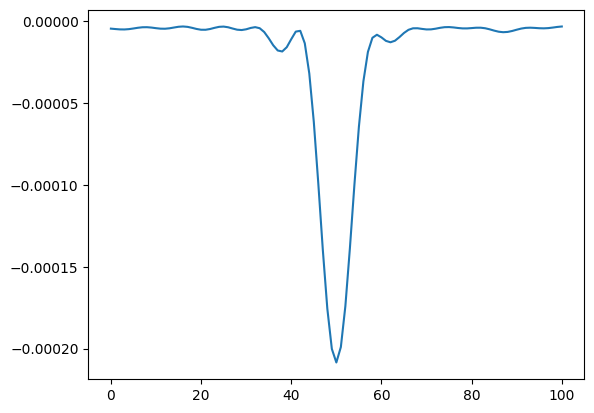

In [36]:
plt.plot(f_alpha)
# print(f_alpha[argmax])

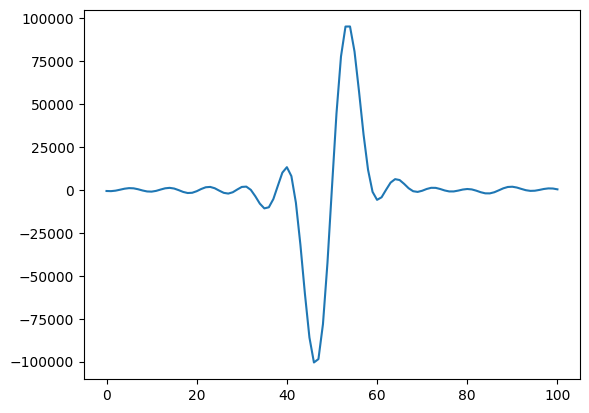

In [38]:
plt.plot(df)

In [129]:
16384*T_SPECTRA*4

68.719476736

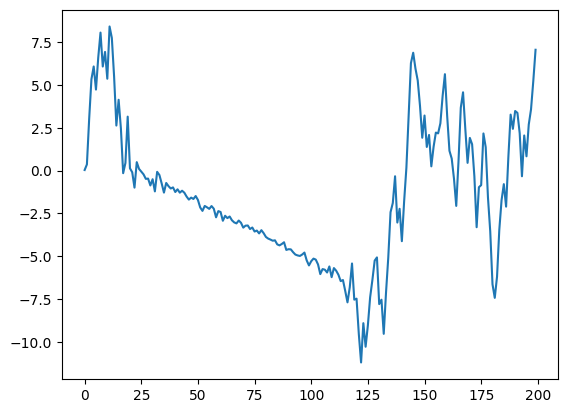

In [119]:
plt.plot(np.unwrap(np.angle(xcorr)[50,100:300]))

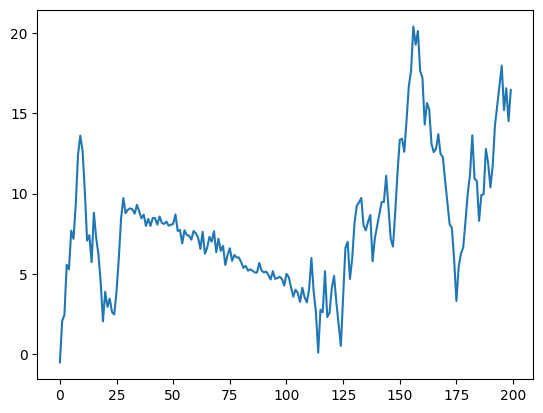

In [127]:
plt.plot(np.unwrap(np.angle(xcorr)[5,100:300]))

### Absolute time offset checks

In [55]:
t_offset = np.linspace(-1,1,5)
print(t_offset)

[-1.  -0.5  0.   0.5  1. ]


-1.0
catalog #57166 epoch 2025-07-22 18:35:47 UTC
-0.5
catalog #57166 epoch 2025-07-22 18:35:47 UTC
0.0
catalog #57166 epoch 2025-07-22 18:35:47 UTC
0.5
catalog #57166 epoch 2025-07-22 18:35:47 UTC
1.0
catalog #57166 epoch 2025-07-22 18:35:47 UTC


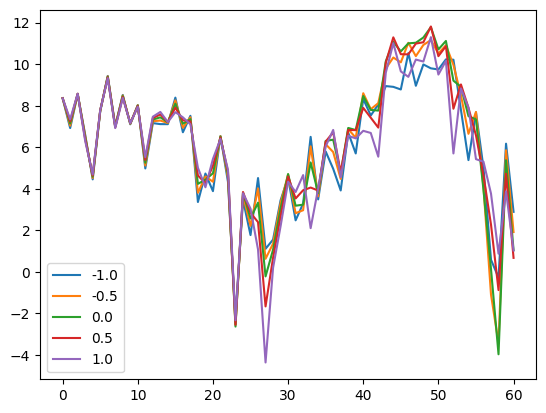

In [56]:
for offset in t_offset:
    print(offset)
    t_start=1753216695+offset
    t_end=1753216960+offset
    a1_coords=[79.4183154,-90.667425,59.364]
    a2_coords=[79.3979952,-90.799868,42.692]
    tle_path = outils.get_tle_file(t_start, "/project/rrg-sievers/mohanagr/OCOMM_TLES")
    dly = outils.get_sat_delay(
                        a1_coords,
                        a2_coords,
                        tle_path,
                        t_start,
                        int(t_end-t_start)+1,
                        57166,
                    )
    delay = np.interp(
        np.arange(0, data.shape[2]) * T_SPECTRA, np.arange(0, int(t_end-t_start)+1), dly
    )
    spec2_phased = np.empty_like(spec2)
    spec2_phased = apply_delay(spec2, spec2_phased, -delay, freqs)
    xcorr = xcorr_avg(spec1,spec2_phased,4096)
    plt.plot(10*np.log10(np.abs(xcorr)[:,150]),label=str(offset))
plt.legend()
plt.show()


Green (0 offset) is sub-dominant in some parts, and dominant in some other parts.
That's because the drift due to bad abs time is degenrate with clock drift

catalog #57166 epoch 2025-07-22 18:35:47 UTC
catalog #57166 epoch 2025-07-22 18:35:47 UTC


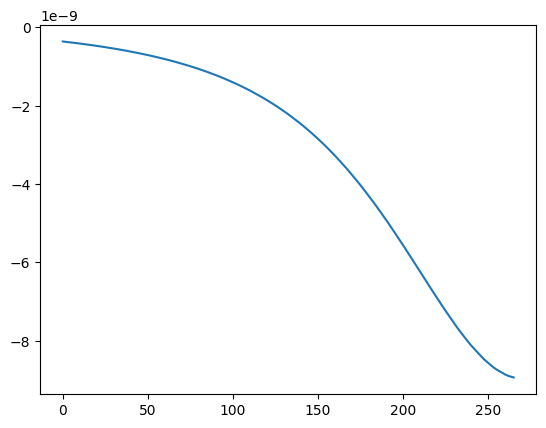

In [51]:
t_start=1753216695
t_end=1753216960
a1_coords=[79.4183154,-90.667425,59.364]
a2_coords=[79.3979952,-90.799868,42.692]
tle_path = outils.get_tle_file(t_start, "/project/rrg-sievers/mohanagr/OCOMM_TLES")
dly1 = outils.get_sat_delay(
                    a1_coords,
                    a2_coords,
                    tle_path,
                    t_start,
                    int(t_end-t_start)+1,
                    57166,
                )
dly2 = outils.get_sat_delay(
                    a1_coords,
                    a2_coords,
                    tle_path,
                    t_start+1e-1,
                    int(t_end-t_start)+1,
                    57166,
                )
plt.plot(dly2-dly1)